# Vespa BGE-M3 Hybrid Retrieval — Nepali Evaluation
Drop-in replacement for the Chroma eval notebook. Uses the same `RetrievalEvaluator` class and all plots.

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
CORPUS_CSV_PATH      = "company_ne.csv"
QUERIES_JSON_PATH    = "eval_queries_ne.json"
EVALUATION_SAVING_DIR = "vespa_bge_m3_V3/"


VESPA_URL="https://d99cfdd3.da6a5f46.z.vespa-app.cloud/"
VESPA_CERT="/home/an00b/.vespa/anupstenant.nepali-m3-eval3.default/data-plane-public-cert.pem"
VESPA_KEY="/home/an00b/.vespa/anupstenant.nepali-m3-eval3.default/data-plane-private-key.pem"


TOP_K_RETRIEVAL = 10
QUERY_TIMEOUT   = "30s"


In [8]:
import pandas as pd
import json
import numpy as np
import time
import os
import torch
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Dict, Any, Optional
from tqdm import tqdm

from FlagEmbedding import BGEM3FlagModel
from vespa.application import Vespa

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [9]:
model = BGEM3FlagModel("BAAI/bge-m3", use_fp16=(device == "cuda"))

Fetching 30 files: 100%|██████████| 30/30 [00:00<00:00, 25827.00it/s]


In [10]:
def load_nepali_corpus(file_path):
    df = pd.read_csv(file_path).dropna(subset=['text', 'id', 'section'])
    doc_ids   = df['id'].tolist()
    doc_texts = (df['section'] + " \n " + df['text']).tolist()
    return doc_ids, doc_texts

def load_evaluation_queries(file_path):
    print(f"Loading queries from {file_path}...")
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

doc_ids, doc_texts = load_nepali_corpus(CORPUS_CSV_PATH)
print(f"Loaded {len(doc_ids)} documents.")

Loaded 165 documents.


In [11]:
class VespaM3Manager:
    """
    Drop-in replacement for ChromaManager.
    Exposes the same .search(query_text, k) interface.
    """

    def __init__(self, url: str, cert: str, key: str, model: BGEM3FlagModel, timeout: str = "30s"):
        self.app     = Vespa(url=url, cert=cert, key=key)
        self.model   = model
        self.timeout = timeout

    def _encode(self, query_text: str) -> dict:
        return self.model.encode(
            [query_text],
            return_dense=True,
            return_sparse=True,
            return_colbert_vecs=True,
        )

    def search(self, query_text: str, k: int = 10) -> List[str]:
        """Returns top-K document IDs from Vespa."""
        q = self._encode(query_text)

        colbert_vecs  = q["colbert_vecs"][0]
        q_colbert     = {str(i): vec.tolist() for i, vec in enumerate(colbert_vecs)}
        q_len_colbert = float(len(colbert_vecs))

        response = self.app.query(
            yql=f"""
                select id from nepali_docs where
                userQuery() or
                ({{targetHits:{k}}}nearestNeighbor(dense_rep, q_dense));
            """,
            ranking="m3hybrid",
            hits=k,
            body={
                "input.query(q_dense)":       q["dense_vecs"][0].tolist(),
                "input.query(q_lexical)":     {str(tk): float(tv) for tk, tv in q["lexical_weights"][0].items()},
                "input.query(q_colbert)":     q_colbert,
                "input.query(q_len_colbert)": q_len_colbert,
                "timeout": self.timeout,
            },
            query=query_text,
        )

        hits = response.hits if response.hits else []
        return [h["fields"]["id"] for h in hits]


db_manager = VespaM3Manager(
    url=VESPA_URL,
    cert=VESPA_CERT,
    key=VESPA_KEY,
    model=model,
    timeout=QUERY_TIMEOUT,
)

In [12]:
# Quick smoke test — should return a list of IDs
test_ids = db_manager.search("कर्मचारी बोनस", k=3)
print("Smoke test retrieved IDs:", test_ids)

You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Smoke test retrieved IDs: ['company_21_006', 'company_06_006', 'company_04_038']


In [13]:
@dataclass
class EvalResult:
    query: str
    expected_id: str
    retrieved_ids: List[str]
    hit: int
    rank: Optional[int]
    reciprocal_rank: float
    latency_ms: float


class RetrievalEvaluator:

    def __init__(self, db_manager, eval_data: List[Dict[str, Any]], k: int = 10):
        self.db_manager = db_manager
        self.eval_data  = eval_data
        self.k          = k
        self.results: List[EvalResult] = []

    # ── Main Evaluation ───────────────────────────────────────────────────────

    def evaluate(self):
        if not self.eval_data:
            raise ValueError("Evaluation dataset is empty.")
        self.results.clear()

        for item in tqdm(self.eval_data, desc="Evaluating"):
            query_text  = item["query"]
            expected_id = item["expected_id"]
            start = time.perf_counter()

            try:
                retrieved_ids = self.db_manager.search(query_text, k=self.k)
            except Exception as e:
                latency = (time.perf_counter() - start) * 1000
                print(f"\nSearch failed for query: {query_text!r} — {e}")
                self.results.append(EvalResult(
                    query=query_text, expected_id=expected_id,
                    retrieved_ids=[], hit=0, rank=None,
                    reciprocal_rank=0.0, latency_ms=latency,
                ))
                continue

            latency = (time.perf_counter() - start) * 1000

            if expected_id in retrieved_ids:
                rank = retrieved_ids.index(expected_id) + 1
                self.results.append(EvalResult(
                    query=query_text, expected_id=expected_id,
                    retrieved_ids=retrieved_ids, hit=1, rank=rank,
                    reciprocal_rank=1.0 / rank, latency_ms=latency,
                ))
            else:
                self.results.append(EvalResult(
                    query=query_text, expected_id=expected_id,
                    retrieved_ids=retrieved_ids, hit=0, rank=None,
                    reciprocal_rank=0.0, latency_ms=latency,
                ))

    # ── Metrics ───────────────────────────────────────────────────────────────

    def hit_rate(self) -> float:
        return sum(r.hit for r in self.results) / len(self.results) if self.results else 0.0

    def mean_reciprocal_rank(self) -> float:
        return float(np.mean([r.reciprocal_rank for r in self.results])) if self.results else 0.0

    def average_latency(self) -> float:
        return float(np.mean([r.latency_ms for r in self.results])) if self.results else 0.0

    def summary(self):
        print("\n" + "=" * 60)
        print("Vespa BGE-M3 Hybrid — Retrieval Evaluation Results")
        print("=" * 60)
        print(f"K:                  {self.k}")
        print(f"Queries Evaluated:  {len(self.results)}")
        print(f"Hit Rate@{self.k}:       {self.hit_rate():.2%}")
        print(f"MRR:                {self.mean_reciprocal_rank():.4f}")
        print(f"Avg Latency:        {self.average_latency():.2f} ms")
        print("=" * 60)

    # ── Plot Helpers ──────────────────────────────────────────────────────────

    def _save_and_show(self, save_dir: Optional[str], filename: str):
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
            path = os.path.join(save_dir, f"{filename}.png")
            plt.savefig(path, bbox_inches='tight', dpi=300)
            print(f"Plot saved to {path}")
        plt.show()

    # ── Plots: Distributions ──────────────────────────────────────────────────

    def plot_hit_miss(self, save_dir: Optional[str] = None):
        hits   = sum(r.hit for r in self.results)
        misses = len(self.results) - hits
        plt.figure(figsize=(6, 4))
        plt.bar(["Hits", "Misses"], [hits, misses], color=['#4CAF50', '#F44336'])
        plt.title("Hit vs Miss")
        plt.ylabel("Count")
        self._save_and_show(save_dir, "plot_hit_miss")

    def plot_rank_distribution(self, save_dir: Optional[str] = None):
        ranks = [r.rank for r in self.results if r.rank is not None]
        if not ranks:
            print("No successful retrievals to plot.")
            return
        plt.figure(figsize=(8, 4))
        plt.hist(ranks, bins=range(1, max(ranks) + 2), align="left",
                 color='#2196F3', edgecolor='black')
        plt.xticks(range(1, max(ranks) + 1))
        plt.title("Correct Document Rank Distribution")
        plt.xlabel("Rank")
        plt.ylabel("Frequency")
        self._save_and_show(save_dir, "plot_rank_distribution")

    def plot_reciprocal_rank_distribution(self, save_dir: Optional[str] = None):
        rrs = [r.reciprocal_rank for r in self.results]
        plt.figure(figsize=(8, 4))
        plt.hist(rrs, bins=10, color='#9C27B0', edgecolor='black')
        plt.title("Reciprocal Rank Distribution")
        plt.xlabel("Reciprocal Rank")
        plt.ylabel("Frequency")
        self._save_and_show(save_dir, "plot_reciprocal_rank_distribution")

    def plot_latency_distribution(self, save_dir: Optional[str] = None):
        latencies = [r.latency_ms for r in self.results]
        plt.figure(figsize=(8, 4))
        plt.hist(latencies, bins=20, color='#FF9800', edgecolor='black')
        plt.title("Latency Distribution")
        plt.xlabel("Latency (ms)")
        plt.ylabel("Frequency")
        self._save_and_show(save_dir, "plot_latency_distribution")

    # ── Plots: Curves ─────────────────────────────────────────────────────────

    def _get_max_k_retrievals(self, max_k: int, desc: str) -> List[tuple]:
        """Fetch max_k results once so curve generation doesn't re-query per k."""
        results = []
        for item in tqdm(self.eval_data, desc=desc, leave=False):
            results.append(
                (item["expected_id"], self.db_manager.search(item["query"], k=max_k))
            )
        return results

    def plot_recall_curve(self, max_k: int = 20, save_dir: Optional[str] = None):
        all_retrievals = self._get_max_k_retrievals(max_k, "Recall curve")
        recalls = [
            sum(1 for eid, rids in all_retrievals if eid in rids[:k]) / len(self.eval_data)
            for k in range(1, max_k + 1)
        ]
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, max_k + 1), recalls, marker="o", color="#E91E63")
        plt.title("Recall@K Curve")
        plt.xlabel("K")
        plt.ylabel("Recall")
        plt.grid(True, linestyle='--', alpha=0.7)
        self._save_and_show(save_dir, "plot_recall_curve")

    def plot_hit_rate_curve(self, max_k: int = 20, save_dir: Optional[str] = None):
        all_retrievals = self._get_max_k_retrievals(max_k, "Hit rate curve")
        hit_rates = [
            sum(1 for eid, rids in all_retrievals if eid in rids[:k]) / len(self.eval_data)
            for k in range(1, max_k + 1)
        ]
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, max_k + 1), hit_rates, marker="o", color="#3F51B5")
        plt.title("Hit Rate@K Curve")
        plt.xlabel("K")
        plt.ylabel("Hit Rate")
        plt.grid(True, linestyle='--', alpha=0.7)
        self._save_and_show(save_dir, "plot_hit_rate_curve")

    def plot_mrr_curve(self, max_k: int = 20, save_dir: Optional[str] = None):
        all_retrievals = self._get_max_k_retrievals(max_k, "MRR curve")
        mrrs = []
        for k in range(1, max_k + 1):
            rrs = []
            for eid, rids in all_retrievals:
                top_k = rids[:k]
                rrs.append(1.0 / (top_k.index(eid) + 1) if eid in top_k else 0.0)
            mrrs.append(float(np.mean(rrs)))
        plt.figure(figsize=(8, 5))
        plt.plot(range(1, max_k + 1), mrrs, marker="o", color="#009688")
        plt.title("MRR@K Curve")
        plt.xlabel("K")
        plt.ylabel("MRR")
        plt.grid(True, linestyle='--', alpha=0.7)
        self._save_and_show(save_dir, "plot_mrr_curve")

    # ── Error Analysis ────────────────────────────────────────────────────────

    def failed_queries(self) -> List[EvalResult]:
        failures = [r for r in self.results if r.hit == 0]
        print(f"\nFailed queries ({len(failures)}/{len(self.results)}):")
        for r in failures:
            print(f"  Q: {r.query!r}  expected: {r.expected_id}  got: {r.retrieved_ids}")
        return failures

In [14]:
eval_data = load_evaluation_queries(QUERIES_JSON_PATH)

evaluator = RetrievalEvaluator(
    db_manager=db_manager,
    eval_data=eval_data,
    k=TOP_K_RETRIEVAL,
)

# evaluator.evaluate()
# evaluator.summary()

Loading queries from eval_queries_ne.json...


In [15]:
# evaluator.plot_hit_miss(save_dir=EVALUATION_SAVING_DIR)
# evaluator.plot_rank_distribution(save_dir=EVALUATION_SAVING_DIR)
# evaluator.plot_reciprocal_rank_distribution(save_dir=EVALUATION_SAVING_DIR)
# evaluator.plot_latency_distribution(save_dir=EVALUATION_SAVING_DIR)

Plot saved to vespa_bge_m3_first_app/plot_recall_curve.png


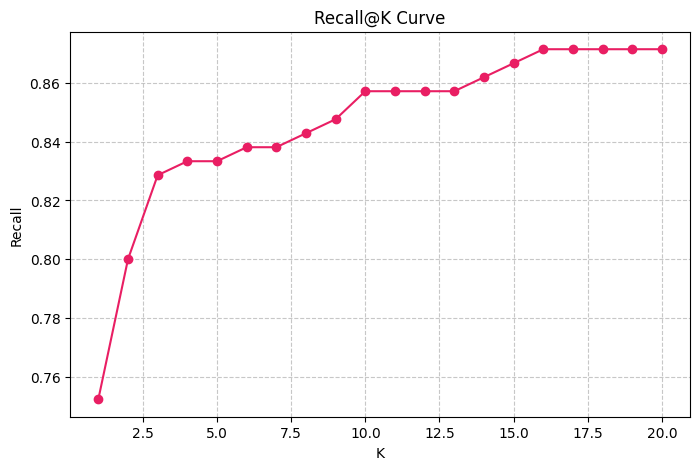

Plot saved to vespa_bge_m3_first_app/plot_hit_rate_curve.png


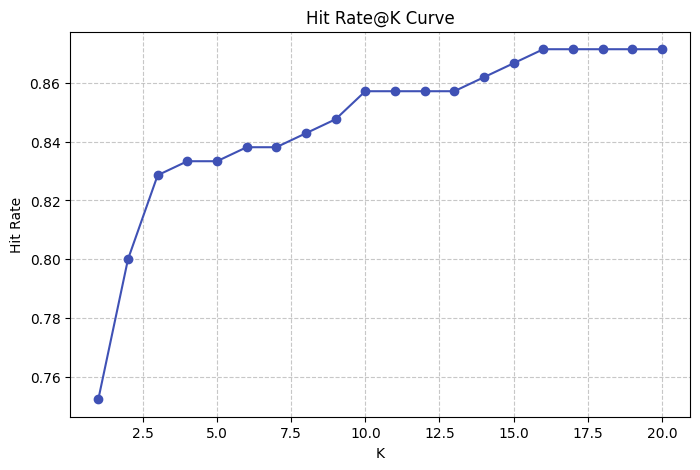

Plot saved to vespa_bge_m3_first_app/plot_mrr_curve.png


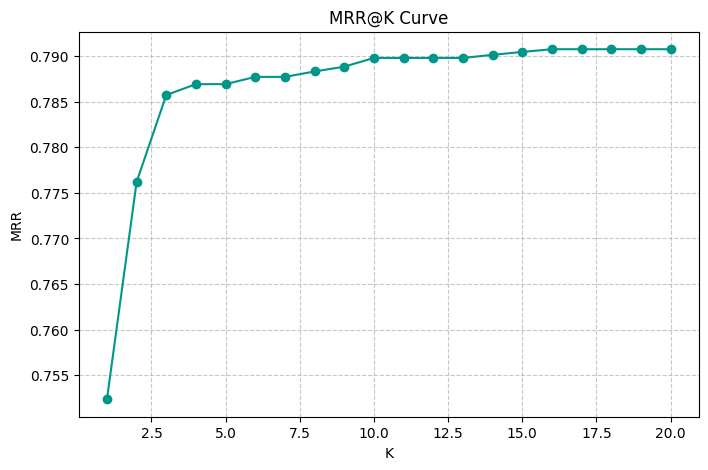

In [16]:
evaluator.plot_recall_curve(max_k=20, save_dir=EVALUATION_SAVING_DIR)
evaluator.plot_hit_rate_curve(max_k=20, save_dir=EVALUATION_SAVING_DIR)
evaluator.plot_mrr_curve(max_k=20, save_dir=EVALUATION_SAVING_DIR)

In [17]:
failures = evaluator.failed_queries()


Failed queries (0/0):
